In [27]:
a = 3

# California Housing

- Hello World

In [28]:
print("Hello world!")
print(a)

Hello world!
3


In [29]:
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing(as_frame=True)

# Access the features (X) and target (y)
df = housing.frame
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [30]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 3 cose da controllare durante il describe:
1. Controllare che minimo e massimo abbiano senso (AveRooms e AveOccup sono anomali).
2. Controllare il rapporto tra media e deviazione standard. Se è maggiore di 1, c'è una forte dispersione di dati su quella colonna (AveOccup e Population).
3. Controllare se media e mediana sono simili tra loro, se non lo sono abbiamo una distribuzione che si chiama skewed. Per fixare (riequilibrare) una distribuzione skewed si raggruppano i dati in sezioni esponenzialmente crescenti. L'inversa dell'esponenziale sarebbe il log (logaritmo), quindi applicando una funzione logaritmica il grafico si bilancerà.
Dunque: se media << 50% applico una trasformazione logaritmica per bilanciare.


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## Cose da controllare durante il df.info
1. Controllare le colonne che hanno dei nulli.
2. Controllare le colonne che non sono numeri (perché la matematica non sa gestire le stringhe).

## Gestione valori nulli
- Se nulli < 5% rimuovo le righe nulle.
- Se nulli < 15/20% sostituisco con medie i numeri e moda le stringhe.
- Se nulli > 20% o elimino la colonna o creo un modello di machine learning per predire i nulli.

### Sostituzione con media
Immaginiamo un dataset con età e guadagno. Ho il 10% dei nulli su guadagno.
Raggruppo in fasce di età e faccio la media di ogni fascia, sostituisco i nulli del guadagno in base all'età associata.

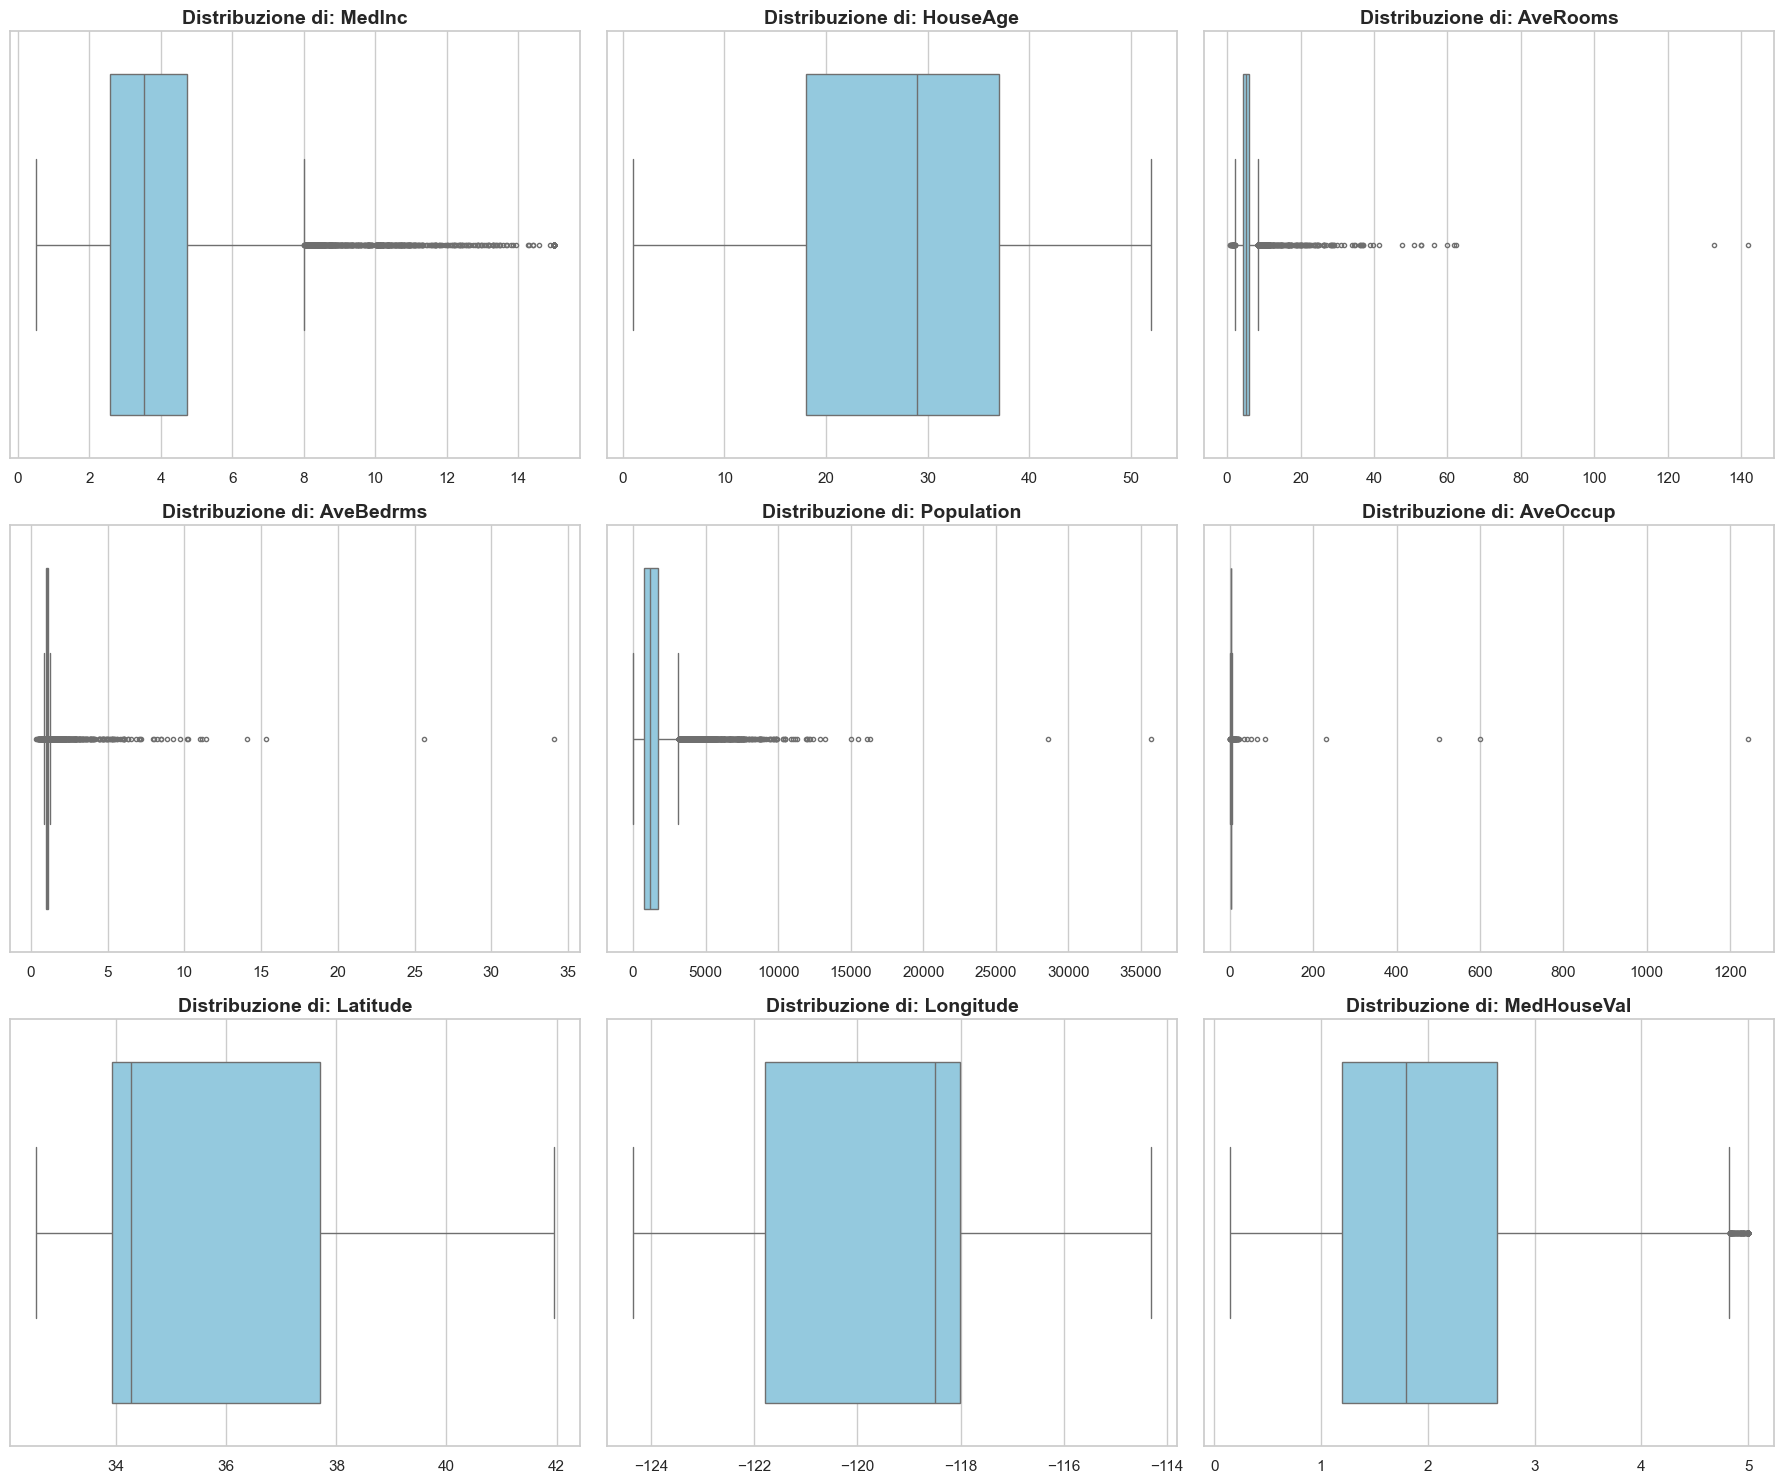

In [32]:
#creami un boxplot sul dataframe
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Impostiamo lo stile e la griglia
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten() # Appiattiamo la matrice di assi per iterare facilmente

# 3. Ciclo per creare un boxplot per ogni colonna
for i, col in enumerate(df.columns):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue', fliersize=3)
    axes[i].set_title(f'Distribuzione di: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('') # Rimuoviamo l'etichetta x per pulizia

# 4. Ottimizzazione del layout
plt.tight_layout()
plt.show()

### Cosa rappresentano le linee verticali del boxplot?
- Le linee verticali rappresentano i valori minimi e massimi (non anomali) dei dati in ogni colonna.
### E la parte blu del boxplot?
- La parte blu del boxplot rappresenta l'intervallo interquartile (IQR), quindi il 50% centrale dei dati.
- La linea all'interno del box rappresenta la mediana.
### I pallini?
- Sono gli outliers.

## Outliers
Gli outliers possono essere di due tipi:
- Caso statisticamente raro (es.: persona alta 2 metri e 30);
- Errore di inserimento (es.: persona alta 23 metri).

### 1. Metodo IQR (Interquartile Range)

È la tecnica usata dai **boxplot**. Si basa sulla distanza tra il primo quartile ($Q_1$) e il terzo quartile ($Q_3$). Tutto ciò che cade fuori dall'intervallo $[Q_1 - 1.5 \times IQR, Q_3 + 1.5 \times IQR]$ viene considerato outlier.

In [33]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

def remove_outliers_iqr(data, columns):
    df_clean = data.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

# Filtraggio
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean 

# Applichiamolo solo ad alcune colonne critiche (es. MedInc e AveRooms)
df_iqr = remove_outliers_iqr(df, ['MedInc', 'AveRooms', 'AveOccup'])
print(f"Righe rimosse con IQR: {len(df) - len(df_iqr)}")

Righe rimosse con IQR: 711


### 2. Metodo Z-Score (Deviazione Standard)

Questa tecnica si basa sulla distribuzione normale. Si calcola quanto un valore dista dalla media in termini di deviazioni standard ($\sigma$). La formula dello Z-score è:

$$Z = \frac{x - \mu}{\sigma}$$

Solitamente, un valore con uno **Z-score maggiore di 3 o minore di -3** è considerato un outlier estremo (rappresenta meno dello 0.3% dei dati in una distribuzione normale).

In [34]:
import numpy as np
from scipy import stats

def remove_outliers_zscore(data, columns, threshold=3):
    df_clean = data.copy()
    # Calcoliamo lo Z-score assoluto per ogni colonna selezionata
    z_scores = np.abs(stats.zscore(df_clean[columns]))

    # Teniamo solo le righe dove TUTTE le colonne hanno Z < threshold
    filtered_entries = (z_scores < threshold).all(axis=1)
    return df_clean[filtered_entries]

# Applicazione
df_zscore = remove_outliers_zscore(df, ['MedInc', 'AveRooms', 'AveOccup'])
print(f"Righe rimosse con Z-Score: {len(df) - len(df_zscore)}")

Righe rimosse con Z-Score: 482


- IQR è più aggressivo, ma funziona bene anche su distribuzioni più sporche.
- Z-SCORE meno aggressivo, ma funziona solo su dati distribuiti normalmente.

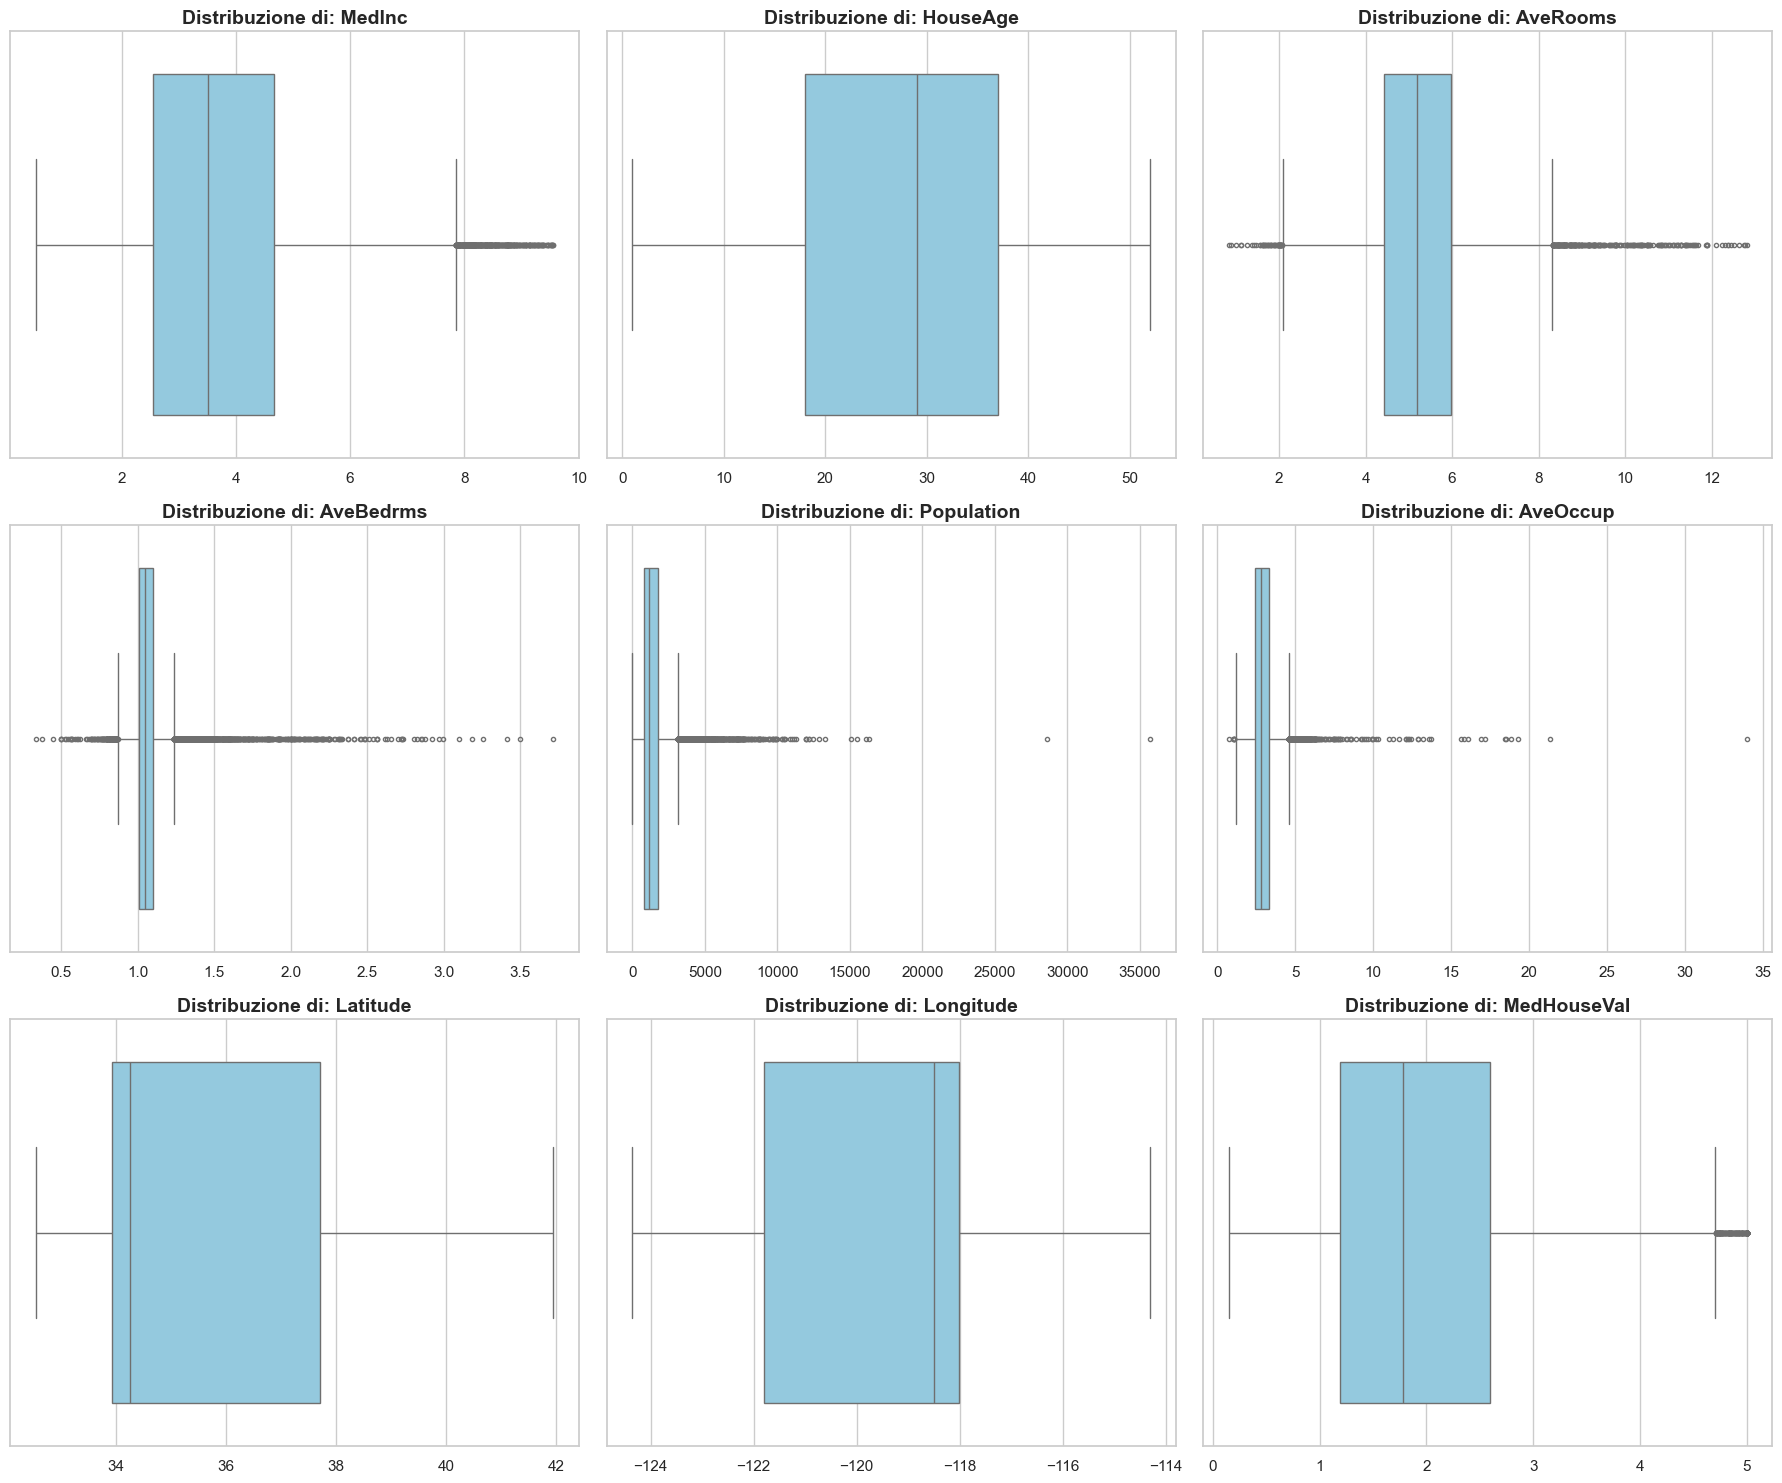

In [35]:
#creami un boxplot sul dataframe
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Impostiamo lo stile e la griglia
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten() # Appiattiamo la matrice di assi per iterare facilmente

# 3. Ciclo per creare un boxplot per ogni colonna
for i, col in enumerate(df_zscore.columns):
    sns.boxplot(x=df_zscore[col], ax=axes[i], color='skyblue', fliersize=3)
    axes[i].set_title(f'Distribuzione di: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('') # Rimuoviamo l'etichetta x per pulizia

# 4. Ottimizzazione del layout
plt.tight_layout()
plt.show()

## Colonne categoriche
Se la colonna è binaria (Sì/No, True/False) trasformiamo in 0, 1.

Se ho più variabili (Milano, Roma, Napoli) assegno ad ogni variabile un numero.

Ma qui sorge un problema: con la nuova configurazione, per il computer Milano + Roma = Napoli. Non posso dunque applicarla su variabili scollegate.

Se avessi piccolo-medio-grande, che hanno un rapporto di grandezza, potrei farlo. Ma se sono scollegate, devo procedere diversamente.

Creo una colonna binaria per ogni opzione:

nuova_colonna: isMilano che contiene True o False ossia 0 o 1. Lo stesso per Roma (isRoma) e Napoli (isNapoli).

Attenzion che se ho 100 opzioni, sto aggiungendo 100 dimensioni.

### 1. Label Encoding

Il `LabelEncoder` trasforma le stringhe in numeri progressivi ($0, 1, 2, ...$).

In [36]:
from sklearn.preprocessing import LabelEncoder

# Esempio: Target con tre classi
y = ['Basso', 'Medio', 'Alto', 'Basso', 'Alto']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Classi originali: {le.classes_}")
print(f"Valori trasformati: {y_encoded}")
# Output: [1, 2, 0, 1, 0] (l'ordine è spesso alfabetico)

Classi originali: ['Alto' 'Basso' 'Medio']
Valori trasformati: [1 2 0 1 0]


### 2. One-Hot Encoding

Questa è la tecnica standard per le variabili categoriche senza un ordine intrinseco (es. "Colore", "Città"). Crea una nuova colonna binaria ($0$ o $1$) per ogni categoria.

In [39]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# DataFrame di esempio
df_test = pd.DataFrame({'Città': ['Roma', 'Milano', 'Napoli', 'Roma']})

# Inizializziamo l'encoder
# sparse_output=False serve per avere un array NumPy leggibile (non una matrice sparsa)
ohe = OneHotEncoder(sparse_output=False)

# Trasformazione
ohe_transformed = ohe.fit_transform(df_test[['Città']])

# Creiamo un nuovo DataFrame con i nomi delle colonne corretti
df_ohe = pd.DataFrame(ohe_transformed, columns=ohe.get_feature_names_out(['Città']))

print(df_ohe)

   Città_Milano  Città_Napoli  Città_Roma
0           0.0           0.0         1.0
1           1.0           0.0         0.0
2           0.0           1.0         0.0
3           0.0           0.0         1.0


## Visualizziamo le distribuzioni delle colonne

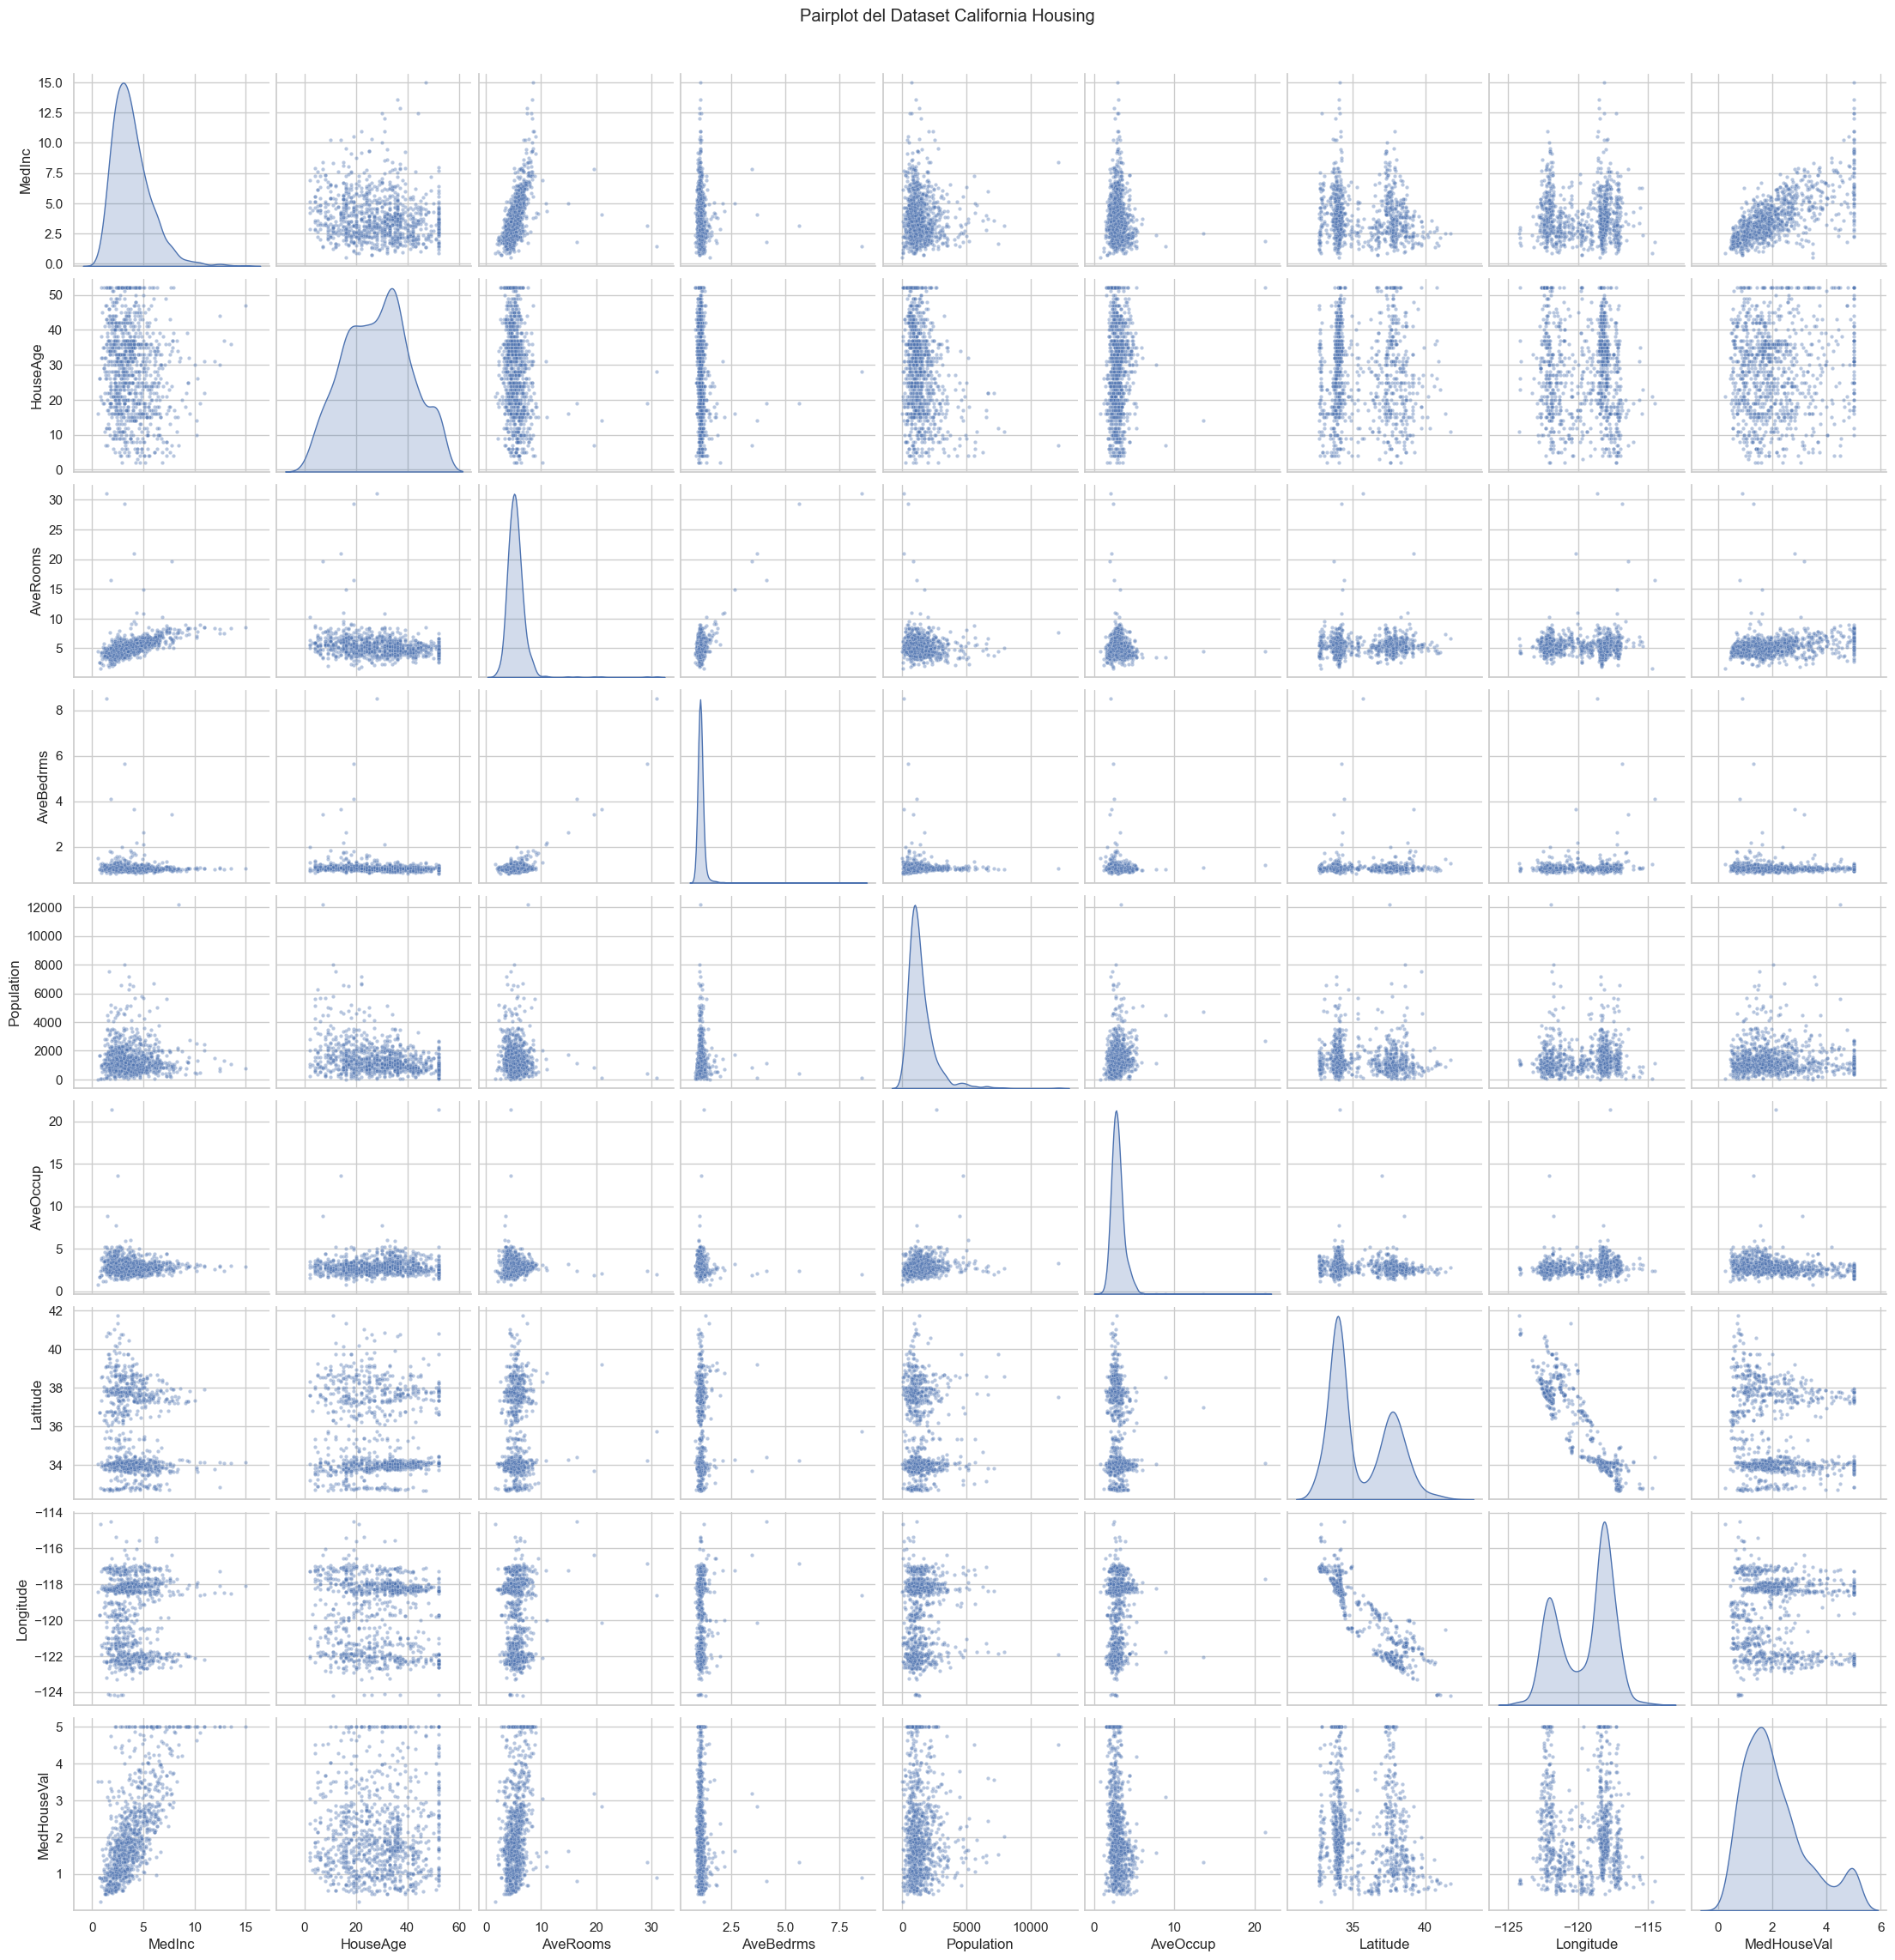

In [38]:
# Campionamento per velocità e chiarezza (es. 1000 righe)
df_sample = df.sample(n=1000, random_state=42, replace=True)

# Creazione del Pairplot
# 'diag_kind' imposta i grafici sulla diagonale (istogrammi o densità KDE)
# 'plot_kws' serve per rimpicciolire i punti e renderli trasparenti
sns.pairplot(df_sample,
diag_kind='kde',
plot_kws={'alpha': 0.4, 's': 10})

plt.suptitle("Pairplot del Dataset California Housing", y=1.02)
plt.show()

Da questo grafico noto che:

- Ho delle variabili lineari tra di loro, soprattutto la variabile MedHouseVal
- Ho distribuzioni gaussiane, un po' skewed (potrei applicare una trasformazione logaritmica)
- I due picchi di Longidute e Latitude sono dovuti a San Francisco e Los Angeles 

## Matrice di correlazione

### Correlazione di Pearson
Ottima per trovare variabili dipendenti tra di loro. Sono interessanti tutte le correlazioni superiori a + 0.15 e inferiori di -0.15.